LAGRANGE INTERPOLATION


Lagrange Interpolating Polynomial:
 3     
x  + 17


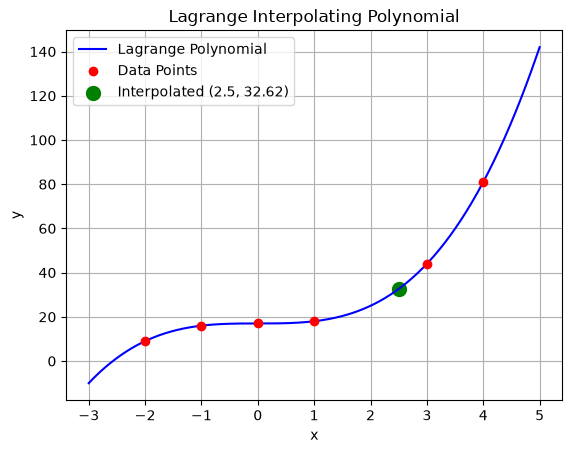


Interpolated value at x = 2.5: y = 32.62


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp


def lagrange_interpolation(x_values, y_values):
    """
    Compute the Lagrange interpolating polynomial for given data points.

    Parameters:
    x_values : list or array : x-coordinates of data points
    y_values : list or array : y-coordinates of data points

    Returns:
    polynomial : sympy expression : The Lagrange polynomial
    """
    x = sp.Symbol('x')
    n = len(x_values)
    L = 0

    for i in range(n):
        term = y_values[i]
        for j in range(n):
            if i != j:
                term *= (x - x_values[j]) / (x_values[i] - x_values[j])
        L += term

    return sp.simplify(L)


def plot_lagrange(x_values, y_values, polynomial, x_interp=None):
    """
    Plot the Lagrange interpolating polynomial along with the data points
    and an interpolated value.

    Parameters:
    x_values : list or array : x-coordinates of data points
    y_values : list or array : y-coordinates of data points
    polynomial : sympy expression : The Lagrange polynomial
    x_interp : float (optional) : The x value at which to evaluate the polynomial
    """
    x = sp.Symbol('x')
    f_lambdified = sp.lambdify(x, polynomial, 'numpy')

    x_plot = np.linspace(min(x_values) - 1, max(x_values) + 1, 500)
    y_plot = f_lambdified(x_plot)

    plt.plot(x_plot, y_plot, label="Lagrange Polynomial", color='blue')
    plt.scatter(x_values, y_values, color='red', label="Data Points", zorder=3)

    if x_interp is not None:
        y_interp = f_lambdified(x_interp)
        plt.scatter(
            [x_interp],
            [y_interp],
            color='green',
            marker='o',
            s=100,
            label=f"Interpolated ({x_interp}, {y_interp:.2f})"
        )

    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Lagrange Interpolating Polynomial')
    plt.legend()
    plt.grid(True)
    plt.show()

    return y_interp if x_interp is not None else None


# Example Usage
# x_vals = [1, 2, 3, 4]
# y_vals = [1, 4, 9, 16]

# Example Usage
x_vals = [-2, -1, 0, 1, 3, 4]
y_vals = [9, 16, 17, 18, 44, 81]

poly = lagrange_interpolation(x_vals, y_vals)
print("Lagrange Interpolating Polynomial:")
sp.pprint(poly)  # Pretty print the polynomial

# Define the point to interpolate
x_interp_val = 2.5

y_interp_val = plot_lagrange(x_vals, y_vals, poly, x_interp_val)

print(f"\nInterpolated value at x = {x_interp_val}: y = {y_interp_val:.2f}")